# «Прогноз отмены бронирования и оценка экономической эффективности для сети отелей UrbanStay»

## Перевод бизнес-задачи на язык машинного обучения

**Задача проекта** — построить ML‑модель, которая прогнозирует вероятность отмены бронирования в сети отелей UrbanStay. Цель не просто в высокой точности предсказаний, а в максимизации экономической выгоды: нужно минимизировать финансовые потери и по возможности не снижать загрузку номеров.

**Ключевой бизнес‑ориентир** — метрика Incremental Revenue (IR): она должна отражать реальный прирост дохода благодаря модели. Модель будет использоваться для принятия решений о том, стоит ли, например, перебронировать номер или оставить бронь «как есть».

**Проект разбит на 4 этапа:**

- Подготовка данных: загрузка из PostgreSQL, EDA, объединение таблиц по правилу «ближайший предыдущий отзыв», создание новых признаков (в т. ч. векторизация текстов отзывов).
- Моделирование: обучение и подбор моделей (Random Forest, CatBoost, LightGBM, XGBoost и др.), оптимизация гиперпараметров через Optuna, калибровка, подбор оптимального порога классификации под максимальный IR, проверка стабильности метрик на калибровочной и тестовой выборках, анализ важности признаков (SHAP/feature_importances).
- Расчёт экономической эффективности: сравнение показателей до и после внедрения модели (доля отмен, загрузка, IR), проверка достижения целевых значений: доля отмен ≤ 10 %, снижение загрузки ≤ 8 %, относительный прирост IR ≥ 50 %.
- Оформление выводов: структурированное описание проделанной работы и бизнес‑интерпретация результатов с рекомендациями.

**Особенность задачи** — сильная бизнес‑привязка: не просто «хорошая модель по AUC/F1», а модель, которая даёт измеримый финансовый эффект и не ухудшает загрузку. Поэтому критически важны корректный расчёт IR, подбор порога и интерпретация признаков с точки зрения влияния на бизнес.

**Данные для решения задачи**

Данные хранятся в PostgreSQL‑базе data-scientist-hotels на сервере Yandex Cloud. Для работы нужны две таблицы:

- hotel_bookings — основная таблица бронирований. В ней содержится информация о самих бронях, включая дату бронирования (booking_date), вероятно, даты заезда/выезда, данные о клиенте, отеле, типе номера, депозите, стоимости и т. д. Целевая переменная — факт отмены бронирования (бинарная: отменена/не отменена).
- hotel_reviews — таблица отзывов. В ней есть review_date, оценки клиентов и текстовые комментарии.

**Ключевые особенности данных и логика их объединения**

Привязка отзывов к бронированию по правилу «для каждой даты бронирования взять ближайший предыдущий отзыв этого клиента». Это важно, чтобы связать удовлетворённость гостя с конкретной будущей бронью. Технически это решается через сортировку по дате и поиск ближайшей предыдущей записи 

**Создание новых признаков на основе данных о бронировании:** сезонность (по дате заезда), лояльность клиента (количество предыдущих бронирований), длительность проживания, время между бронированием и заездом и т. п.

**Признаки из текстов отзывов:** векторизация текста (например, TfidfVectorizer) для получения числовых представлений тональности, тематики и силы отзыва. Это позволит модели учитывать прошлый опыт клиента.

**Категориальные и количественные признаки:** в обеих таблицах будут как числовые (длительность, стоимость, количество бронирований), так и категориальные (тип номера, город, тип клиента) переменные, требующие кодирования.

**Пропуски, дубликаты, аномалии:** на этапе EDA нужно проверить качество данных, выявить и обработать пропуски, удалить дубликаты, проверить корректность дат и диапазонов значений (например, отрицательные длительности, невозможные даты).

## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

In [1]:
!pip install optuna -q
!pip install --upgrade xgboost -q
!pip install phik -q
!pip install shap -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import optuna
import shap
import psycopg2

from phik import phik_matrix
from catboost import Pool, CatBoostClassifier
from xgboost import XGBClassifier


from sqlalchemy import create_engine
from sklearn.preprocessing import LabelEncoder
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, brier_score_loss
from sklearn.calibration import calibration_curve

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score, StratifiedKFold



## подготовка данных

### Загрузка данных

Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).

In [3]:
# Параметры подключения
host = "rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net"
port = 6432
database = "data-scientist-hotels"
user = "praktikum_student"
password = "Sdf4$2;d-d30pp"

# Формируем строку подключения (PostgreSQL)
conn_str = f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}"

# Создаём движок
engine = create_engine(conn_str)

# Выгружаем таблицы
query_bookings = "SELECT * FROM hotel_bookings;"
query_reviews = "SELECT * FROM hotel_reviews;"

df_bookings = pd.read_sql_query(query_bookings, engine)
df_reviews = pd.read_sql_query(query_reviews, engine)

print("hotel_bookings shape:", df_bookings.shape)
print("hotel_reviews shape:", df_reviews.shape)

hotel_bookings shape: (35341, 17)
hotel_reviews shape: (25177, 5)


In [4]:
display(df_bookings.head())
display(df_reviews.head())

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


In [5]:
n_before = len(df_bookings)

**hotel_bookings (бронирования)**

`booking_id`	Уникальный номер брони. С помощью него можно идентифицировать каждое бронирование в системе. Пример номера брони: INN000001310.

`booking_date`	Дата оформления брони: например, 18.06.2018.

`sales_channel`	Способ оформления брони:

    • офлайн_бронирование — бронирование через телефон, ресепшен и другими способами без использования интернета.  
    • онлайн_бронирование — бронирование через сайт или приложение.  
    • корпоративное_бронирование — бронирование от компании или организации.  
    
`adult_count`	Количество взрослых гостей, которые планируют заселиться в отель. Например, 2 означает, что в рамках брони в отель планируют заехать как минимум двое взрослых, не считая детей.

`child_count`	Количество детей, которые заселятся в отель в рамках брони. Например, 0 означает, что детей среди ожидаемых гостей нет.

`returning_customer`	Отметка о том, что клиенты уже бронировали номера в сети отелей. 1 — бронь уже была, 0 — новый клиент.

`previous_cancellations`	Количество отменённых бронирований у клиента в прошлом. Например, 0 означает, что клиент ни разу не отменял бронирование, а 2 — что он два раза отменял бронь.

`previous_no_shows`	Сколько раз клиент бронировал номер и по итогу заселялся. 1 означает, что клиент один раз действительно заехал по своей брони, 0 — пока подтверждений брони не было.

`booking_value`	Итоговая стоимость бронирования в рублях.

`days_until_checkin`	Количество дней с момента брони до даты заселения. Например, 204 означает, что между бронью и заездом должно было пройти 204 дня.

`weekend_nights`	Количество ночей в периоде проживания, которые приходятся на выходные дни — субботу и воскресенье. Например, 4 означает, что гости будут проживать четыре ночи в выходные дни.

`weekday_nights`	Количество ночей в периоде проживания, которые приходятся на будние дни: с понедельника по пятницу. Например, 2 означает, что гости будут проживать две ночи в будние дни.

`meal_plan`	Выбранный гостями тип питания. Примеры значений: тип_питания_1, тип_питания_2.

`parking_included`	Информация о бронировании парковочного места. Например, 0 означает, что парковка не бронировалась.

`room_type`	Категория номера или номеров в брони. Примеры значений: тип_1, тип_4.

`customer_special_requests`	Количество комментариев и пожеланий клиента: например, просьб о дополнительной кровати, раннем заезде и так далее.

`booking_status`	Целевая переменная, обозначает текущий статус бронирования:
    • отказ_брони — бронирование было отменено.  
    • нет_отказа — бронирование активно, не отменено.  


**hotel_reviews (отзывы)**

`customer_id`	Уникальный идентификатор клиента, например, C0003. Используется, чтобы связать отзыв и его автора, конкретного гостя.

`booking_id`	Идентификатор брони, по которой оставлен отзыв. Например, INN000201614 — это номер бронирования, который связывает отзыв с конкретной поездкой.

`review_date`	Дата, когда клиент оставил отзыв: например, 2018-11-21. Показывает, когда была получена обратная связь.

`stay_rating`	Оценка, которую клиент поставил проживанию. 1 — низший балл, 5 — высший балл.

`review_text`	Развёрнутый комментарий клиента о проживании. В этом поле содержится качественная обратная связь: что понравилось, а что нет. Пример отзыва: «Неплохо. Приветливый персонал на ресепшн, но завтрак однообразный. Питание в ресторане понравилось».

Данные из базы PostgreSQL были загружены в pandas‑DataFrame с помощью библиотеки SQLAlchemy и функции pd.read_sql_query. Использованы две целевые таблицы: hotel_bookings (бронирования) и hotel_reviews (отзывы). Подключение выполнено по указанным параметрам (хост, порт, пользователь, пароль). Такой подход позволяет гибко выгружать данные SQL‑запросом и сразу работать с ними в Python без промежуточного экспорта.

### Исследовательский анализ данных и предобработка

In [6]:
display(df_bookings.info())
display(df_reviews.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  object
 1   booking_id   25177 non-null  object
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  object
dtypes: int64(1), object(4)
memory usage: 983.6+ KB


None

- hotel_bookings (35 341 запись) — полноценная таблица бронирований без пропусков.
- hotel_reviews (25 177 записей) — компактная таблица отзывов, тоже без пропусков:

In [7]:
display(df_bookings.describe())
display(df_reviews.describe())

,adult_count,child_count,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,customer_special_requests
count,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000
mean,12.479726,0.358988,0.356923,0.839535,61634.055219,100.523726,6.532922,1.953991,0.621488
std,45.726290,0.587324,0.628771,0.931724,42837.589968,71.872677,3.339492,1.477249,0.784391
min,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,33500.000000,45.000000,5.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,1.000000,53600.000000,90.000000,6.000000,2.000000,0.000000
75%,3.000000,1.000000,1.000000,1.000000,80400.000000,144.000000,9.000000,2.000000,1.000000
max,300.000000,2.000000,5.000000,5.000000,417221.200000,300.000000,15.000000,6.000000,5.000000


,stay_rating
count,25177.000000
mean,3.395321
std,0.541434
min,2.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000


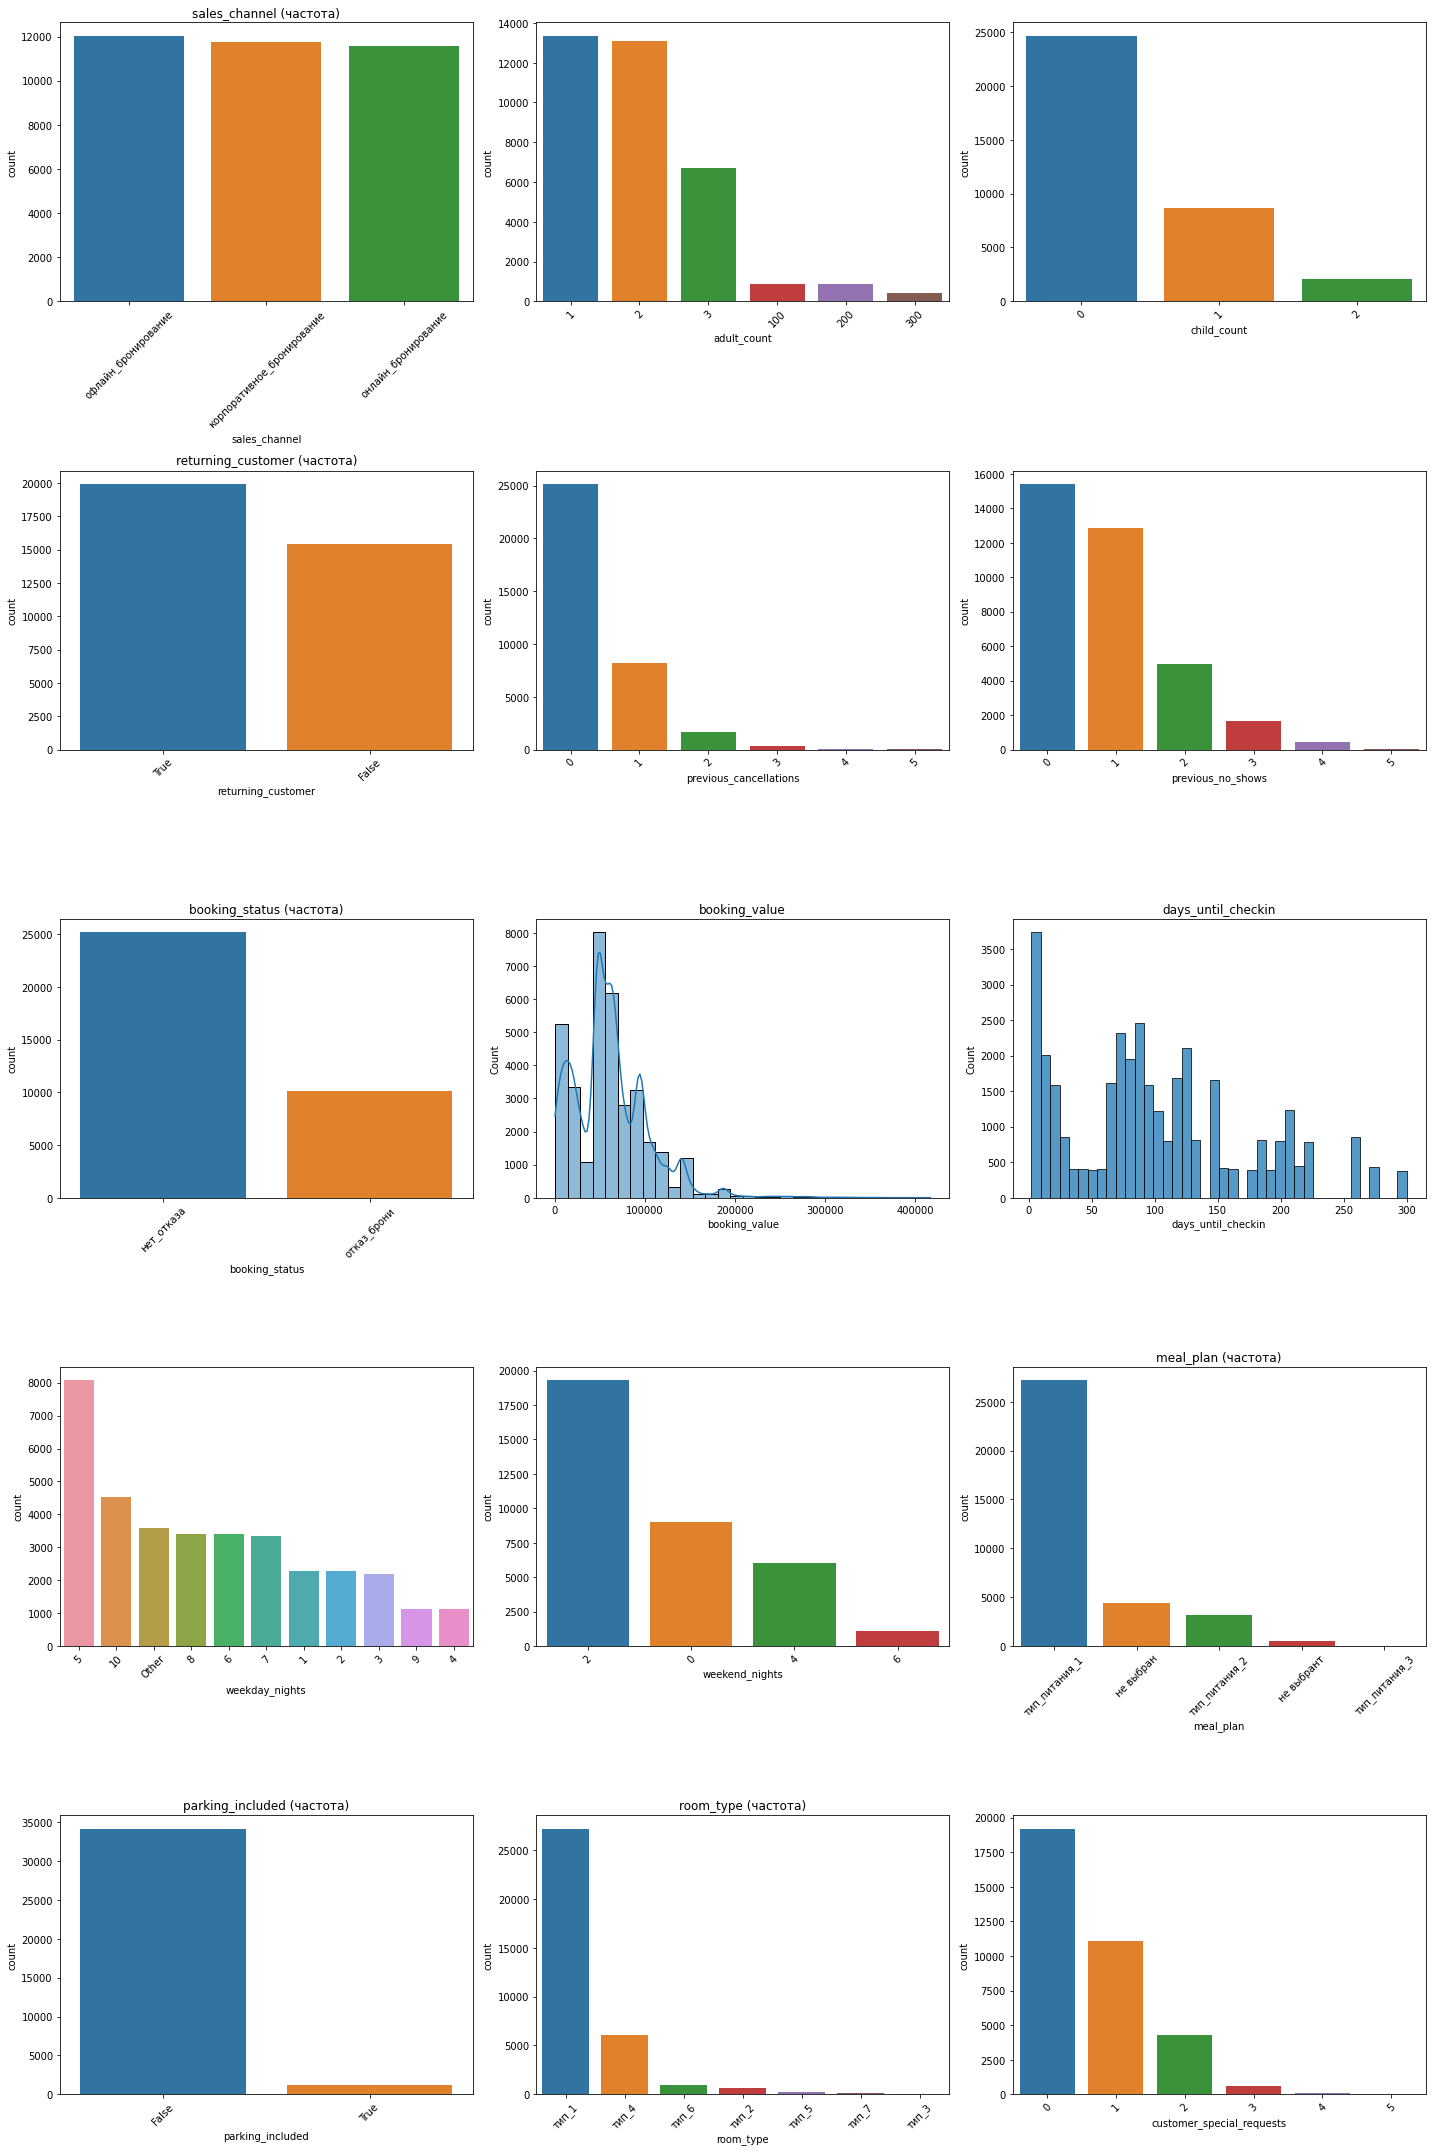

In [8]:
all_cols = [
    'sales_channel', 'adult_count', 'child_count', 'returning_customer',
    'previous_cancellations', 'previous_no_shows', 'booking_status',
    'booking_value', 'days_until_checkin', 'weekday_nights', 'weekend_nights',
    'meal_plan', 'parking_included', 'room_type', 'customer_special_requests'
]

# Разделим признаки по типу визуализации
cat_cols = ['sales_channel', 'booking_status', 'returning_customer', 'meal_plan', 'parking_included', 'room_type']
count_cols = ['adult_count', 'child_count', 'previous_cancellations', 'customer_special_requests',
             'weekday_nights', 'weekend_nights', 'previous_no_shows']  
num_cols = ['booking_value', 'days_until_checkin']

# Подберём размер сетки: 3 колонки, строки посчитаем автоматически
n_cols = 3
n_rows = (len(all_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes = axes.ravel()

for i, col in enumerate(all_cols):
    ax = axes[i]
    
    if col in cat_cols:
        # Для категорий: countplot
        order = df_bookings[col].value_counts().index
        sns.countplot(data=df_bookings, x=col, ax=ax, order=order)
        ax.set_title(f"{col} (частота)")
        ax.tick_params(axis='x', rotation=45)
    
    elif col in count_cols:
        # Для счётчиков 
        top_vals = df_bookings[col].value_counts().head(10).index
        df_tmp = df_bookings.copy()
        df_tmp[col] = df_tmp[col].where(df_tmp[col].isin(top_vals), 'Other')
        order = df_tmp[col].value_counts().index
        sns.countplot(data=df_tmp, x=col, ax=ax, order=order)
        ax.tick_params(axis='x', rotation=45)
    
    elif col in num_cols:
        # Для чисел:
        if col == 'booking_value':
            sns.histplot(data=df_bookings, bins = 30, x=col, kde=True, ax=ax)
            ax.set_title(f"{col}")
        else:
            sns.histplot(data=df_bookings, bins = 40, x=col, kde=False, ax=ax)
            ax.set_title(f"{col}")

# Скрываем пустые подграфики, если их осталось
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [9]:
for col in all_cols:
    print(f'Распределение значений {col}')
    print(df_bookings[col].value_counts())
    print('='*50)

Распределение значений sales_channel
офлайн_бронирование           12040
корпоративное_бронирование    11747
онлайн_бронирование           11554
Name: sales_channel, dtype: int64
Распределение значений adult_count
1      13361
2      13102
3       6727
100      884
200      872
300      395
Name: adult_count, dtype: int64
Распределение значений child_count
0    24683
1     8629
2     2029
Name: child_count, dtype: int64
Распределение значений returning_customer
True     19928
False    15413
Name: returning_customer, dtype: int64
Распределение значений previous_cancellations
0    25152
1     8198
2     1624
3      304
4       59
5        4
Name: previous_cancellations, dtype: int64
Распределение значений previous_no_shows
0    15413
1    12843
2     4948
3     1657
4      440
5       40
Name: previous_no_shows, dtype: int64
Распределение значений booking_status
нет_отказа     25177
отказ_брони    10164
Name: booking_status, dtype: int64
Распределение значений booking_value
46900.0     5

**Баланс целевой переменной (отмены)**  
- Нет отказа: 25 177 бронирований (≈ 71,3 %)
- Отказ брони: 10 164 бронирования (≈ 28,7 %)

Вывод: задача умеренно несбалансирована (примерно 2,5:1). Для скоринга и IR это нормально: можно использовать AUC/PR‑AUC, а в качестве пороговой метрики — F1 или максимизацию IR. Сильного перекоса нет, поэтому агрессивная балансировка (SMOTE) не обязательна — лучше работать с class_weight и подбором порога.

**Каналы продаж (sales_channel)**  
- Офлайн‑бронирование: 12 040 (≈ 34,1 %)
- Корпоративное: 11 747 (≈ 33,2 %)
- Онлайн: 11 554 (≈ 32,7 %)

Вывод: каналы распределены почти равномерно, без явного доминирования одного. Это значит, что эффект модели и IR нужно считать по сегментам, а не «в среднем по отелю». Если модель покажет, что в одном канале отмены прогнозируются лучше, IR будет выше именно там.

**Взрослые и дети (adult_count, child_count)** — есть аномалии  

adult_count:

- Основная масса: 1–3 взрослых (≈ 94 % всех бронирований).
- Аномальные значения: 100, 200, 300 (суммарно ≈ 6,5 %).

Cкорее всего, это групповые/корпоративные брони, где в одной строке учтено сразу много гостей. В ML такие выбросы могут «ломать» распределения и ухудшать линейные модели.

child_count:

- 0 детей: 24 683 (≈ 69,8 %)
- 1 ребёнок: 8 629 (≈ 24,4 %)
- 2 ребёнка: 2 029 (≈ 5,7 %)

Вывод: большинство бронирований без детей, распределение естественное.

**Лояльность и история поведения (returning_customer, previous_cancellations, previous_no_shows)**  

- Returning_customer = True: 19 928 (≈ 56,4 %) — более половины бронирований от повторных клиентов.
- Previous_cancellations: у 25 152 (≈ 71,2 %) клиентов их не было; у остальных — 1–5 отмен.
- Previous_no_shows: у 15 413 (≈ 43,6 %) не было no‑show; у остальных — 1–5 случаев.

Бизнес‑вывод: история клиента — сильный предиктор. Повторные клиенты и клиенты без прошлых отмен/no‑show должны иметь меньший риск отмены. 

**Стоимость бронирования (booking_value)**  

- Уникальных значений: 1 766 (много разных цен).
- Есть явные «ступеньки» (46 900, 53 600, 60 300, 67 000 и т. д.) — вероятно, это тарифы по типам номеров и длительности.
- Присутствуют экстремальные значения (до ~331 153), но их мало — это выбросы.

Сделать booking_value_log (логарифм) — распределение станет ближе к нормальному, модели будут стабильнее.  

**Дни до заезда (days_until_checkin)**

- Много разных значений (79 уникальных), есть пики на 6–150 днях.
- Распределение не равномерное: есть выраженные «скопления» на определённых сроках.

Гипотеза: ранние и поздние брони имеют разный риск отмены. Например, брони за 7 дней могут быть более рискованными, чем за 150 дней. 

**Длительность проживания (weekday_nights, weekend_nights)**  

- Weekday_nights: преобладают 5–8 ночей.
- Weekend_nights: чаще всего 2 ночи, реже 0 или 4.

**Питание, парковка, тип номера (meal_plan, parking_included, room_type)**  

meal_plan:

- «тип_питания_1»: 27 182 (≈ 77 %) — явно доминирует.

Есть опечатки/дубли: «не выбран» и «не выбрант» — нужно привести к единому значению.

parking_included:

- False: 34 165 (≈ 96,7 %) — парковка почти никогда не включена.
- True: 1 176 (≈ 3,3 %).

room_type:

- «тип_1»: 27 197 (≈ 76,9 %) — основной тип.
- Остальные типы — в разы меньше.

**Специальные запросы (customer_special_requests)**  
- 0 запросов: 19 200 (≈ 54,3 %)
- 1 запрос: 11 113 (≈ 31,4 %)
- 2 запроса: 4 322 (≈ 12,2 %)
- Дальше — быстро падает.

Вывод: признак полезный: клиенты с запросами могут иметь иной профиль риска (например, чаще отменяют из‑за неисполнения запроса). 


In [10]:
# Избавляемся от опечаток
df_bookings['meal_plan'] = df_bookings['meal_plan'].replace(
    ['не выбрант', 'не выбран'], 
    'не выбран'
)

df_bookings['booking_date'] = pd.to_datetime(df_bookings['booking_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])

print(df_bookings['meal_plan'].value_counts())

тип_питания_1    27182
не выбран         4933
тип_питания_2     3219
тип_питания_3        7
Name: meal_plan, dtype: int64


**Проверим данные на дубликаты**

In [11]:
booking_duplicated = df_bookings.duplicated().sum()
print(booking_duplicated)

reviews_duplicated = df_reviews.duplicated().sum()
print(reviews_duplicated)

4608
0


4608 явных дубликатов в таблице `bookings`

In [12]:
df_bookings = df_bookings.drop_duplicates()

**Проверим данные на дублирование броней**

In [13]:
booking_id_duplicated = df_bookings.duplicated(subset = ['booking_id']).sum()
print(booking_id_duplicated)

0


Значени > 100 в поле с количеством взрослых, являются аномалиями. Скорее всего это ошибка записи(лишние нули)

In [14]:
#Корректируем аномалии
mask_fix_adult = (df_bookings['adult_count'] % 100 == 0) & (df_bookings['adult_count'] >= 100)
df_bookings.loc[mask_fix_adult, 'adult_count'] = df_bookings.loc[mask_fix_adult, 'adult_count'] // 100

In [15]:
df_bookings['adult_count'].describe()

count    30733.000000
mean         1.799597
std          0.751473
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: adult_count, dtype: float64

In [16]:
#удаление некорректных бронирований (booking_value = 0)
n_zero_val = (df_bookings['booking_value'] == 0).sum()
df_bookings = df_bookings[df_bookings['booking_value'] > 0].copy()

n_after = len(df_bookings)

print(f"До очистки: {n_before} записей")
print(f"Удалено строк с booking_value=0: {n_zero_val}")
print(f"После очистки: {n_after} записей")

До очистки: 35341 записей
Удалено строк с booking_value=0: 1229
После очистки: 29504 записей


### Объединение таблиц

- Соединим таблицу отзывов с таблицей бронирований. Руководствуемся правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

In [17]:
df = df_bookings.merge(
    df_reviews[['customer_id', 'booking_id']],
    on='booking_id',
    how='left'
)

reviews_sorted = df_reviews.sort_values('review_date')
bookings_sorted = df.sort_values('booking_date')

df = pd.merge_asof(
    bookings_sorted,
    reviews_sorted,
    by='customer_id',
    left_on='booking_date',
    right_on='review_date',
    direction='backward',
    allow_exact_matches=False
)
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32659 entries, 0 to 32658
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id_x               32659 non-null  object        
 1   booking_date               32659 non-null  datetime64[ns]
 2   sales_channel              32659 non-null  object        
 3   adult_count                32659 non-null  int64         
 4   child_count                32659 non-null  int64         
 5   returning_customer         32659 non-null  bool          
 6   previous_cancellations     32659 non-null  int64         
 7   previous_no_shows          32659 non-null  int64         
 8   booking_status             32659 non-null  object        
 9   booking_value              32659 non-null  float64       
 10  days_until_checkin         32659 non-null  int64         
 11  weekday_nights             32659 non-null  int64         
 12  week

(32659, 22)

In [18]:
display(df.head())

,booking_id_x,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,...,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,booking_id_y,review_date,stay_rating,review_text
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67000.0,...,2,тип_питания_2,False,тип_2,0,C11662,NaN,NaT,NaN,NaN
1,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67000.0,...,2,тип_питания_2,False,тип_2,0,C11662,NaN,NaT,NaN,NaN
2,INN00177,2017-01-01,онлайн_бронирование,2,0,False,0,0,отказ_брони,67000.0,...,2,тип_питания_2,False,тип_1,0,NaN,NaN,NaT,NaN,NaN
3,INN20018,2017-01-01,онлайн_бронирование,3,0,True,1,1,отказ_брони,46900.0,...,2,тип_питания_1,False,тип_1,2,NaN,NaN,NaT,NaN,NaN
4,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67000.0,...,2,тип_питания_2,False,тип_2,0,C11662,NaN,NaT,NaN,NaN


### Создание новых признаков

In [19]:
def feature_engineering(df):
    
    # Флаг: был ли у клиента хотя бы один отзыв до этой брони
    df['has_prior_review'] = df['review_date'].notna().astype(int)

    # Дней с последнего отзыва (если был)
    df['days_since_last_review'] = (df['booking_date'] - df['review_date']).dt.days
    df['days_since_last_review'] = df['days_since_last_review'].fillna(9999)

    # Рейтинг: если нет отзыва, ставим специальное значение
    df['stay_rating_filled'] = df['stay_rating'].fillna(-1)
    
    # Для текста: флаг наличия текста
    df['has_review_text'] = df['review_text'].notna().astype(int)

    # Дата заезда: booking_date + days_until_checkin
    df['checkin_date'] = df['booking_date'] + pd.to_timedelta(df['days_until_checkin'], unit='D')

    # Месяц заезда 
    df['checkin_month'] = df['checkin_date'].dt.month

    # Общая длительность проживания 
    df['stay_duration_days'] = df['weekday_nights'] + df['weekend_nights']
    
    # Защита от нулевых/отрицательных значений
    df['stay_duration_days'] = df['stay_duration_days'].clip(lower=1)

    # Общее число гостей
    df['total_guests'] = df['adult_count'] + df['child_count']

    # Стоимость одной ночи (средняя)
    
    duration_safe = df['stay_duration_days'].replace(0, np.nan)
    df['price_per_night'] = df['booking_value'] / duration_safe
    df['price_per_night'] = df['price_per_night'].fillna(0)

    # Доля выходных ночей в бронировании
    df['weekend_share'] = np.where(
        df['stay_duration_days'] > 0,
        df['weekend_nights'] / df['stay_duration_days'],
        0.0
    )

    return df

In [20]:
df = feature_engineering(df)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32659 entries, 0 to 32658
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id_x               32659 non-null  object        
 1   booking_date               32659 non-null  datetime64[ns]
 2   sales_channel              32659 non-null  object        
 3   adult_count                32659 non-null  int64         
 4   child_count                32659 non-null  int64         
 5   returning_customer         32659 non-null  bool          
 6   previous_cancellations     32659 non-null  int64         
 7   previous_no_shows          32659 non-null  int64         
 8   booking_status             32659 non-null  object        
 9   booking_value              32659 non-null  float64       
 10  days_until_checkin         32659 non-null  int64         
 11  weekday_nights             32659 non-null  int64         
 12  week

In [22]:
# Проверяем дубликаты
dup_count = df[df.duplicated()].shape[0]
print('Дубли по booking_id:', dup_count)

# Удаляем дубли 
df = df.drop_duplicates()

Дубли по booking_id: 3155


### Анализ итоговой таблицы

In [23]:
display(df.head())
df.info()

,booking_id_x,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,...,has_prior_review,days_since_last_review,stay_rating_filled,has_review_text,checkin_date,checkin_month,stay_duration_days,total_guests,price_per_night,weekend_share
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67000.0,...,0,9999.0,-1.0,0,2017-05-05,5,10,5,6700.0,0.200000
2,INN00177,2017-01-01,онлайн_бронирование,2,0,False,0,0,отказ_брони,67000.0,...,0,9999.0,-1.0,0,2017-03-15,3,10,2,6700.0,0.200000
3,INN20018,2017-01-01,онлайн_бронирование,3,0,True,1,1,отказ_брони,46900.0,...,0,9999.0,-1.0,0,2017-03-25,3,7,3,6700.0,0.285714
5,INN22445,2017-01-01,офлайн_бронирование,2,0,False,0,0,нет_отказа,71200.0,...,0,9999.0,-1.0,0,2017-03-27,3,8,2,8900.0,0.250000
6,INN17387,2017-01-01,офлайн_бронирование,2,0,True,1,1,нет_отказа,73700.0,...,0,9999.0,-1.0,0,2017-03-21,3,11,2,6700.0,0.181818


<class 'pandas.core.frame.DataFrame'>
Int64Index: 29504 entries, 0 to 32658
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id_x               29504 non-null  object        
 1   booking_date               29504 non-null  datetime64[ns]
 2   sales_channel              29504 non-null  object        
 3   adult_count                29504 non-null  int64         
 4   child_count                29504 non-null  int64         
 5   returning_customer         29504 non-null  bool          
 6   previous_cancellations     29504 non-null  int64         
 7   previous_no_shows          29504 non-null  int64         
 8   booking_status             29504 non-null  object        
 9   booking_value              29504 non-null  float64       
 10  days_until_checkin         29504 non-null  int64         
 11  weekday_nights             29504 non-null  int64         
 12  week

1. Целевая переменная (таргет)
booking_status: Наша целевая перменная. 
- 1 - бронь отмененая
- 0 - бронь осталась

2. Типы признаков и их пригодность для модели
ID и служебные колонки (не подавать в модель)
- `booking_id_x, booking_id_y, customer_id` — однозначно исключить.

- `booking_date` — использовать только для time‑based split, в модель не подавать.

Категориальные признаки 
- `sales_channel` 
- `meal_plan`
- `room_type`
- `booking_status` 


Числовые признаки

- `adult_count, child_count, total_guests` — счётчики гостей.
- `previous_cancellations, previous_no_shows` — поведенческие индикаторы риска.
- `days_until_checkin` — важный признак: чем ближе заезд, тем ниже риск отмены (обычно).
- `weekday_nights, weekend_nights` — уже использованы для расчёта длительности и доли выходных.
- `stay_duration_days, weekend_share` — агрегированные метрики бронирования.
- `price_per_night` — нормализованная стоимость, полезна для разделения «дешёвых/дорогих» сегментов.
- `customer_special_requests` — может быть индикатором сложности бронирования.

Даты и временные признаки
- `booking_date, checkin_date` — только для разбиения на train/calib/test.
- `checkin_month` — сезонность (месяц заезда) — хороший признак.

Признаки на основе отзывов (редкие, разреженные)

- `has_prior_review, days_since_last_review, stay_rating_filled, has_review_text` — полезны, но у ~70% строк эти данные отсутствуют (только 8 021 запись с отзывами).


3. Пропуски и разреженность
- `customer_id`: 21 012 из 29 504 непустых → ~29% пропусков. Это нормально: не у всех бронирований есть привязка к клиенту.
Признаки отзывов (review_date, stay_rating, review_text, booking_id_y): только ~8 000 непустых строк → ~73% пропусков.


## Разделение на выборки

In [24]:
df = df.sort_values('booking_date').reset_index(drop=True)

# 1. Целевая переменная
# -------------------------
df['booking_status'] = (df['booking_status'] == 'отказ_брони').astype(int)
target = df['booking_status'].copy()

n = len(df)

# 2. Считаем индексы разбиения строго по количеству строк
train_end = int(n * 0.6)           
calib_end  = int(n * 0.8)           
# test — остаток (оставшиеся 20%)

df_train = df.iloc[:train_end].copy()
df_calib = df.iloc[train_end:calib_end].copy()
df_test  = df.iloc[calib_end:].copy()

print("Размеры выборок:")
print(f"Train: {len(df_train)} ({len(df_train)/n:.2%})")
print(f"Calib: {len(df_calib)} ({len(df_calib)/n:.2%})")
print(f"Test:  {len(df_test)}  ({len(df_test)/n:.2%})")

X_train_base = df_train.drop(columns = 'booking_status')
y_train = df_train['booking_status']

X_calib_base = df_calib.drop(columns = 'booking_status')
y_calib = df_calib['booking_status']

X_test_base = df_test.drop(columns = 'booking_status')
y_test = df_test['booking_status']


# -------------------------
# 3. Сначала берём тексты для TF-IDF 
# -------------------------
train_texts = X_train_base['review_text'].fillna('').astype(str)
calib_texts = X_calib_base['review_text'].fillna('').astype(str)
test_texts = X_test_base['review_text'].fillna('').astype(str)

# -------------------------
# 4. Теперь удаляем лишние колонки
# -------------------------
drop_cols = [
    'booking_status', 'booking_id', 'booking_id_x', 'booking_id_y',
    'customer_id', 'booking_date', 'review_date',
    'booking_status', 'review_text', 'checkin_date'
]
cols_to_drop = [c for c in drop_cols if c in df.columns]

X_train_base = X_train_base.drop(columns=cols_to_drop, errors='ignore')
X_calib_base = X_calib_base.drop(columns=cols_to_drop, errors='ignore')
X_test_base = X_test_base.drop(columns=cols_to_drop, errors='ignore')

# -------------------------
# 5. Категориальные признаки
cat_features = X_train_base.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_features:
    X_train_base[col] = X_train_base[col].astype('category')
    X_calib_base[col] = X_calib_base[col].astype('category')
    X_test_base[col] = X_test_base[col].astype('category')

# -------------------------
# 6. TF-IDF
# -------------------------
vectorizer = TfidfVectorizer(
    max_features=50,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    lowercase=True
)

tfidf_train = vectorizer.fit_transform(train_texts)
tfidf_calib = vectorizer.transform(calib_texts)
tfidf_test = vectorizer.transform(test_texts)

tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_train.shape[1])]

X_train_tfidf = pd.DataFrame(tfidf_train.toarray(), columns=tfidf_cols, index=X_train_base.index)
X_calib_tfidf = pd.DataFrame(tfidf_calib.toarray(), columns=tfidf_cols, index=X_calib_base.index)
X_test_tfidf = pd.DataFrame(tfidf_test.toarray(), columns=tfidf_cols, index=X_test_base.index)

# Добавляем TF‑IDF к основным признакам
X_train = pd.concat([X_train_base, X_train_tfidf], axis=1)
X_calib = pd.concat([X_calib_base, X_calib_tfidf], axis=1)
X_test = pd.concat([X_test_base, X_test_tfidf], axis=1)

# Обновляем список категориальных признаков: 
cat_features = [c for c in cat_features if c != 'review_text']

Размеры выборок:
Train: 17702 (60.00%)
Calib: 5901 (20.00%)
Test:  5901  (20.00%)


In [25]:
y_train.value_counts()

0    12463
1     5239
Name: booking_status, dtype: int64

## Корреляционный анализ данных

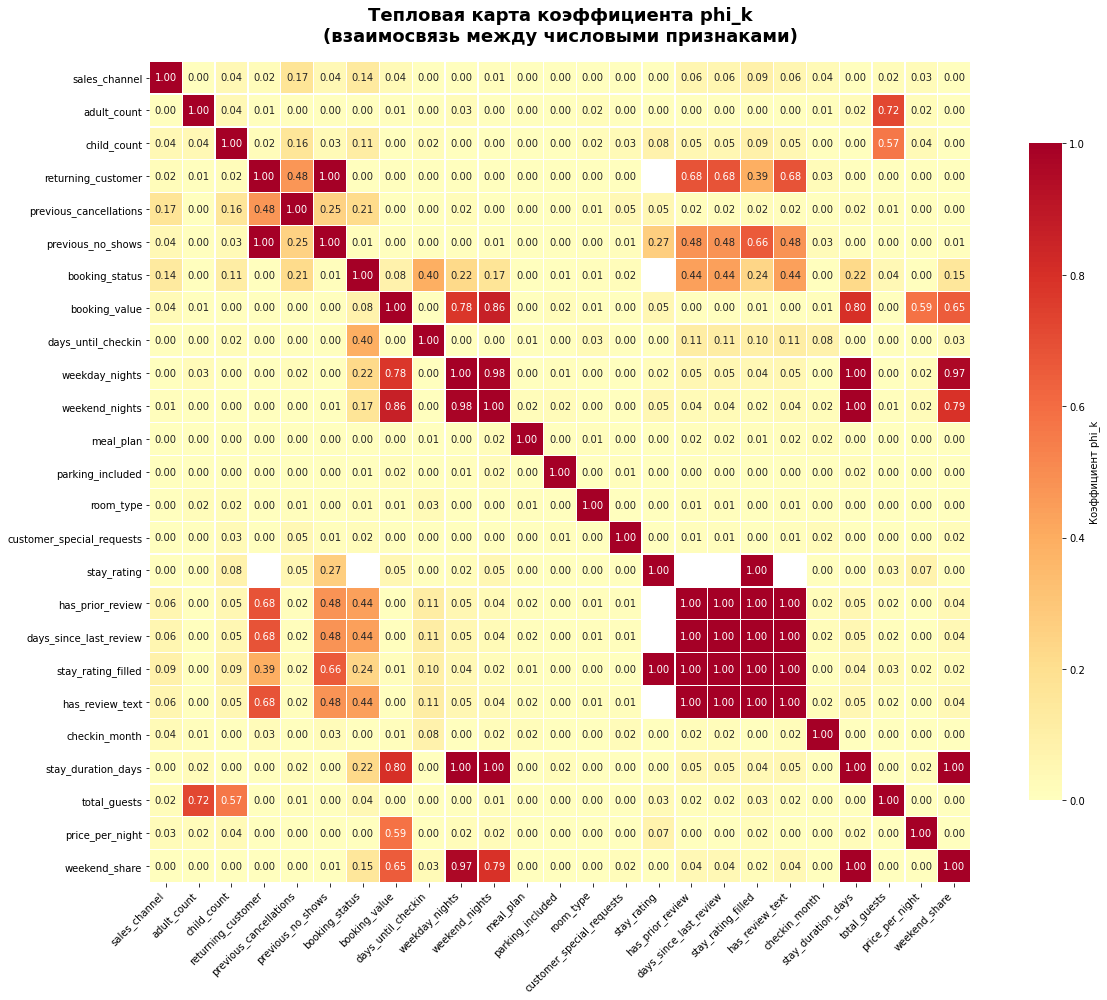

СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.5):
returning_customer ↔ previous_no_shows: 1.000
weekday_nights ↔ stay_duration_days: 1.000
weekend_nights ↔ stay_duration_days: 1.000
stay_rating ↔ stay_rating_filled: 1.000
has_prior_review ↔ days_since_last_review: 1.000
has_prior_review ↔ stay_rating_filled: 1.000
has_prior_review ↔ has_review_text: 1.000
days_since_last_review ↔ stay_rating_filled: 1.000
days_since_last_review ↔ has_review_text: 1.000
stay_rating_filled ↔ has_review_text: 1.000
stay_duration_days ↔ weekend_share: 1.000
weekday_nights ↔ weekend_nights: 0.984
weekday_nights ↔ weekend_share: 0.966
booking_value ↔ weekend_nights: 0.865
booking_value ↔ stay_duration_days: 0.798
weekend_nights ↔ weekend_share: 0.790
booking_value ↔ weekday_nights: 0.778
adult_count ↔ total_guests: 0.719
returning_customer ↔ has_prior_review: 0.681
returning_customer ↔ days_since_last_review: 0.681
returning_customer ↔ has_review_text: 0.681
previous_no_shows ↔ stay_rating_filled: 0.661
booking_value ↔ we

In [26]:
df_corr = df_train.drop(columns=['booking_id', 'checkin_date', 'booking_id_x', 'booking_id_y',
    'customer_id', 'booking_date', 'review_date',
    'review_text'], errors='ignore')

# Вычисляем матрицу корреляций
correlation_matrix = df_corr.phik_matrix(
    interval_cols=[ 'booking_value',
    'price_per_night',
    'days_since_last_review',
    'stay_rating_filled',
    'weekend_share'
    ]
)

# Создаём фигуру с увеличенным размером
plt.figure(figsize=(18, 14))

# Тепловая карта с улучшенной читаемостью
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',  # Красная-жёлтая-синяя палитра (обратная)
    center=0,  # Центрируем цветовую шкалу на 0
    linewidths=0.3,
    linecolor='white',  # Цвет линий между ячейками
    cbar=True,  # Показываем цветовую шкалу
    cbar_kws={'label': 'Коэффициент phi_k', 'shrink': 0.8},
    square=True,
    annot_kws={'size': 10}  # Размер шрифта аннотаций
)

# Настройка заголовка
plt.title(
    'Тепловая карта коэффициента phi_k\n(взаимосвязь между числовыми признаками)',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Поворот меток осей для лучшей читаемости
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Оптимизация расположения элементов
plt.tight_layout()
plt.show()


print("СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.5):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) >= 0.5:
            strong_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

if strong_corr:
    for col1, col2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1} ↔ {col2}: {corr:.3f}")
else:
    print("Сильных корреляций не обнаружено")

- Основаная зависимость с целевой переменной: `has_review_text`, `days_since_last_review`, `has_prior_review`, `days_until_checkin`. 
- Большое количество мультиколлинеарных признаков. В основном это связано с созданием новых из уже существующих. Для деревьев это не проблема

##  Моделирование

### Обучение базовых моделей

In [27]:
AVG_REV = 64500
COST_FP = 7000
PER_REBOOKING = 45000
LOST_REV = 64500

ir_catboost_list = []
ir_xgboost_list = []

tscv = TimeSeriesSplit(n_splits=3, test_size=2000)

def calculate_ir(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    ir_before = ((y_true == 0).sum() * AVG_REV) - ((y_true == 1).sum() * LOST_REV)
    ir_after = (tn * AVG_REV) + (tp * PER_REBOOKING) - (fp * COST_FP) - (fn * LOST_REV)
    return ir_after, ir_before, tp, tn, fp, fn

def get_ir_gain_per_booking(y_true, y_pred):
    ir_after, ir_before, _, _, _, _ = calculate_ir(y_true, y_pred)
    return (ir_after - ir_before) / len(y_true)

for train_idx, val_idx in tscv.split(X_train_base):
    # ---------------------------------------------------------
    # Подготовка TF‑IDF внутри фолда
    # ---------------------------------------------------------
    txt_tr = train_texts.iloc[train_idx]
    txt_val = train_texts.iloc[val_idx]

    vec = TfidfVectorizer(max_features=50, min_df=5, max_df=0.8, ngram_range=(1, 2), lowercase=True)
    tfidf_tr = vec.fit_transform(txt_tr)
    tfidf_val = vec.transform(txt_val)
    tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_tr.shape[1])]

    df_tfidf_tr = pd.DataFrame(tfidf_tr.toarray(), columns=tfidf_cols, index=X_train_base.iloc[train_idx].index)
    df_tfidf_val = pd.DataFrame(tfidf_val.toarray(), columns=tfidf_cols, index=X_train_base.iloc[val_idx].index)

    # ---------------------------------------------------------
    # CatBoost: 
    # ---------------------------------------------------------
    X_tr = X_train_base.iloc[train_idx].copy()
    X_val = X_train_base.iloc[val_idx].copy()
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    X_tr = pd.concat([X_tr, df_tfidf_tr], axis=1)
    X_val = pd.concat([X_val, df_tfidf_val], axis=1)

    current_cat_features = [c for c in cat_features if c in X_tr.columns]

    model_cat = CatBoostClassifier(
        iterations=200,
        l2_leaf_reg=3,
        logging_level='Silent',
        random_state=42,
        thread_count=1,
        early_stopping_rounds=50
    )
    model_cat.fit(X_tr, y_tr, cat_features=current_cat_features)

    probs_cat = model_cat.predict_proba(X_val)[:, 1]

    threshold = 0.5
    preds_cat = (probs_cat > threshold).astype(int)
    
    ir_after, ir_before, _, _, _, _ = calculate_ir(y_val, preds_cat)
    ir_cat = ir_after - ir_before
    ir_catboost_list.append(ir_cat)

    # ---------------------------------------------------------
    # XGBoost:
    # ---------------------------------------------------------

    model_xgb = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        reg_lambda=1.0,
        verbosity=0,
        random_state=42,
        enable_categorical=True,
        early_stopping_rounds=50
    )
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    probs_xgb = model_xgb.predict_proba(X_val)[:, 1]

    threshold = 0.5
    
    preds_xgb = (probs_xgb > threshold).astype(int)
    
    ir_after, ir_before, _, _, _, _ = calculate_ir(y_val, preds_xgb)
    ir_xgb = ir_after - ir_before
    ir_xgboost_list.append(ir_xgb)

print(f"IR (CatBoost): {np.mean(ir_catboost_list):.4f}")
print(f"IR (XGBoost):  {np.mean(ir_xgboost_list):.4f}")

IR (CatBoost): 27711833.3333
IR (XGBoost):  28704166.6667


Базовая модель XGBoost выигрывает 

### Подбор гиперпараметров

In [28]:
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 200),
        'depth': trial.suggest_int('depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 15),
        'logging_level': 'Silent',
        'random_state': 42
    }
    ir_list_optuna = []

    for train_idx, val_idx in tscv.split(X_train_base):
        X_tr = X_train_base.iloc[train_idx].copy()
        X_val = X_train_base.iloc[val_idx].copy()
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        txt_tr = train_texts.iloc[train_idx]
        txt_val = train_texts.iloc[val_idx]

        vec = TfidfVectorizer(max_features=50, min_df=5, max_df=0.8, ngram_range=(1, 2))
        tfidf_tr = vec.fit_transform(txt_tr)
        tfidf_val = vec.transform(txt_val)
        tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_tr.shape[1])]

        X_tr = pd.concat([X_tr, pd.DataFrame(tfidf_tr.toarray(), columns=tfidf_cols, index=X_tr.index)], axis=1)
        X_val = pd.concat([X_val, pd.DataFrame(tfidf_val.toarray(), columns=tfidf_cols, index=X_val.index)], axis=1)

        model = CatBoostClassifier(**params, early_stopping_rounds=50)
        model.fit(X_tr, y_tr, cat_features=cat_features)
        probs_cat = model.predict_proba(X_val)[:, 1]
        
        threshold = 0.5
        preds_cat = (probs_cat > threshold).astype(int)
    
        ir_after, ir_before, _, _, _, _ = calculate_ir(y_val, preds_cat)
        ir_cat = ir_after - ir_before
        ir_list_optuna.append(ir_cat)

    return np.mean(ir_list_optuna)


def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'verbosity': 0,
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    ir_list_optuna = []

    for train_idx, val_idx in tscv.split(X_train_base):
        X_tr = X_train_base.iloc[train_idx].copy()
        X_val = X_train_base.iloc[val_idx].copy()
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        txt_tr = train_texts.iloc[train_idx]
        txt_val = train_texts.iloc[val_idx]

        vec = TfidfVectorizer(max_features=50, min_df=5, max_df=0.8, ngram_range=(1, 2))
        tfidf_tr = vec.fit_transform(txt_tr)
        tfidf_val = vec.transform(txt_val)
        tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_tr.shape[1])]

        X_tr = pd.concat([X_tr, pd.DataFrame(tfidf_tr.toarray(), columns=tfidf_cols, index=X_tr.index)], axis=1)
        X_val = pd.concat([X_val, pd.DataFrame(tfidf_val.toarray(), columns=tfidf_cols, index=X_val.index)], axis=1)

        model = XGBClassifier(**params, enable_categorical=True)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        probs_xgb = model.predict_proba(X_val)[:, 1]
        threshold = 0.5
        preds_xgb = (probs_xgb > threshold).astype(int)
    
        ir_after, ir_before, _, _, _, _ = calculate_ir(y_val, preds_xgb)
        ir_cat = ir_after - ir_before
        ir_list_optuna.append(ir_cat)

    return np.mean(ir_list_optuna)

print("Оптимизация CatBoost...")
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_catboost, n_trials=20, show_progress_bar=True)
print(f"Лучший IR CatBoost: {study_cat.best_value:.0f}")
print(f"Лучшие параметры: {study_cat.best_params}")

print("\nОптимизация XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgboost, n_trials=20, show_progress_bar=True)
print(f"Лучший IR XGBoost: {study_xgb.best_value:.0f}")
print(f"Лучшие параметры: {study_xgb.best_params}")

[I 2026-08-18 11:46:23,321] A new study created in memory with name: no-name-fa405ff3-31bd-4a22-b3a4-dce66b0f8612


Оптимизация CatBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-18 11:46:33,262] Trial 0 finished with value: 25528333.333333332 and parameters: {'iterations': 108, 'depth': 6, 'learning_rate': 0.012778440095357233, 'l2_leaf_reg': 8.73417317733767}. Best is trial 0 with value: 25528333.333333332.
[I 2026-08-18 11:46:42,206] Trial 1 finished with value: 28179666.666666668 and parameters: {'iterations': 138, 'depth': 4, 'learning_rate': 0.09455622013215152, 'l2_leaf_reg': 11.690555204880003}. Best is trial 1 with value: 28179666.666666668.
[I 2026-08-18 11:46:51,601] Trial 2 finished with value: 22618666.666666668 and parameters: {'iterations': 138, 'depth': 4, 'learning_rate': 0.010349442859017339, 'l2_leaf_reg': 11.090506672271315}. Best is trial 1 with value: 28179666.666666668.
[I 2026-08-18 11:47:01,118] Trial 3 finished with value: 28367500.0 and parameters: {'iterations': 147, 'depth': 4, 'learning_rate': 0.192279860526002, 'l2_leaf_reg': 12.376470832806088}. Best is trial 3 with value: 28367500.0.
[I 2026-08-18 11:47:13,988] Trial 

[I 2026-08-18 11:49:46,873] A new study created in memory with name: no-name-1f9501a4-f9bd-43e0-8e4b-5c6e5326f3c4


[I 2026-08-18 11:49:46,867] Trial 19 finished with value: 28731000.0 and parameters: {'iterations': 180, 'depth': 5, 'learning_rate': 0.11573919447131682, 'l2_leaf_reg': 6.147712240405818}. Best is trial 19 with value: 28731000.0.
Лучший IR CatBoost: 28731000
Лучшие параметры: {'iterations': 180, 'depth': 5, 'learning_rate': 0.11573919447131682, 'l2_leaf_reg': 6.147712240405818}

Оптимизация XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-18 11:49:50,263] Trial 0 finished with value: 28807000.0 and parameters: {'n_estimators': 168, 'max_depth': 3, 'learning_rate': 0.1277273835503779, 'reg_lambda': 4.244940027713672, 'subsample': 0.9754931786692711}. Best is trial 0 with value: 28807000.0.
[I 2026-08-18 11:49:53,864] Trial 1 finished with value: 29163833.333333332 and parameters: {'n_estimators': 153, 'max_depth': 4, 'learning_rate': 0.13050770111659216, 'reg_lambda': 2.336742775821337, 'subsample': 0.7548098769425009}. Best is trial 1 with value: 29163833.333333332.
[I 2026-08-18 11:49:57,955] Trial 2 finished with value: 27255166.666666668 and parameters: {'n_estimators': 180, 'max_depth': 4, 'learning_rate': 0.021147629946910867, 'reg_lambda': 2.1827883159925507, 'subsample': 0.6195839570557756}. Best is trial 1 with value: 29163833.333333332.
[I 2026-08-18 11:50:01,595] Trial 3 finished with value: 27683500.0 and parameters: {'n_estimators': 134, 'max_depth': 5, 'learning_rate': 0.03141576118097271, 'reg_l

- По результатам подбора гиперпараметров с помощью библиотеки Optuna модель XGBoost показал лучшие результаты по метрике IR. 
- Лучшие параметры: 'n_estimators': 196, 'max_depth': 5, 'learning_rate': 0.06690054843884428, 'reg_lambda': 4.274553988786167, 'subsample': 0.617574324405513

### Калибровка модели и пересчёт результатов

Делаем подбор оптимального порога отсечения для бинарной классификации под бизнес‑метрику IR (Incremental Revenue / прирост дохода).

In [29]:
final_model = XGBClassifier(**study_xgb.best_params, enable_categorical=True, random_state = 42)
final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.18556920540401864,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=160, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

Brier (до калибровки): 0.1227
Brier (после калибровки): 0.1206


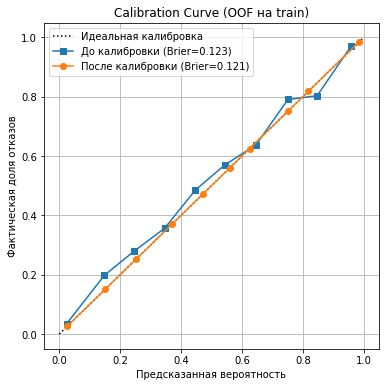

Best Threshold (Calib): 0.376 | IR Calib: 253530000
Test IR with Calib Threshold: 304861500


In [30]:
tfidf_params = {
    "max_features": 50,
    "min_df": 5,
    "max_df": 0.8,
    "ngram_range": (1, 2),
    "lowercase": True
}

# ---------------------------------------------------------
# OOF-прогнозы с переобучением TF-IDF внутри каждого фолда
# ---------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=3, test_size=2000)
oof_probs = np.full_like(y_train.values, np.nan, dtype=float)  

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_base)):
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    if len(np.unique(y_tr)) < 2:
        continue

    # TF-IDF только на train части фолда
    vec = TfidfVectorizer(**tfidf_params)
    train_texts_fold = train_texts.iloc[train_idx]
    val_texts_fold = train_texts.iloc[val_idx]

    tfidf_tr = vec.fit_transform(train_texts_fold)
    tfidf_val = vec.transform(val_texts_fold)

    tfidf_cols = [f"tfidf_{i}" for i in range(tfidf_tr.shape[1])]
    df_tfidf_tr = pd.DataFrame(tfidf_tr.toarray(), columns=tfidf_cols, index=train_idx)
    df_tfidf_val = pd.DataFrame(tfidf_val.toarray(), columns=tfidf_cols, index=val_idx)

    X_tr_feat = pd.concat([
        X_train_base.iloc[train_idx].reset_index(drop=True),
        df_tfidf_tr.reset_index(drop=True)
    ], axis=1)

    X_val_feat = pd.concat([
        X_train_base.iloc[val_idx].reset_index(drop=True),
        df_tfidf_val.reset_index(drop=True)
    ], axis=1)

    model_fold = XGBClassifier(**study_xgb.best_params, enable_categorical=True, random_state=42)
    model_fold.fit(X_tr_feat, y_tr)
    oof_probs[val_idx] = model_fold.predict_proba(X_val_feat)[:, 1]

# Оставляем только строки, где есть реальный OOF-прогноз
mask_valid = ~np.isnan(oof_probs)
oof_probs_valid = oof_probs[mask_valid]
y_train_valid = y_train[mask_valid].values

if mask_valid.sum() == 0:
    raise ValueError("Не удалось получить ни одного OOF-прогноза — проверь разбиение и баланс классов.")

# ---------------------------------------------------------
# 3. Калибратор только на валидных OOF
# ---------------------------------------------------------
iso_calib = IsotonicRegression(out_of_bounds="clip")
iso_calib.fit(oof_probs_valid, y_train_valid)

probs_train_calib_valid = iso_calib.predict(oof_probs_valid)

brier_before = brier_score_loss(y_train_valid, oof_probs_valid)
brier_after = brier_score_loss(y_train_valid, probs_train_calib_valid)
print(f"Brier (до калибровки): {brier_before:.4f}")
print(f"Brier (после калибровки): {brier_after:.4f}")

prob_true_before, prob_pred_before = calibration_curve(y_train_valid, oof_probs_valid, n_bins=10)
prob_true_after, prob_pred_after = calibration_curve(y_train_valid, probs_train_calib_valid, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k:", label="Идеальная калибровка")
plt.plot(prob_pred_before, prob_true_before, "s-", label=f"До калибровки (Brier={brier_before:.3f})")
plt.plot(prob_pred_after, prob_true_after, "o-", label=f"После калибровки (Brier={brier_after:.3f})")
plt.xlabel("Предсказанная вероятность")
plt.ylabel("Фактическая доля отказов")
plt.legend()
plt.title("Calibration Curve (OOF на train)")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 4. Финальная модель (TF-IDF на всём train)
# ---------------------------------------------------------
vec_final = TfidfVectorizer(**tfidf_params)
tfidf_train_final = vec_final.fit_transform(train_texts)
tfidf_calib_final = vec_final.transform(calib_texts)
tfidf_test_final = vec_final.transform(test_texts)

tfidf_cols = [f"tfidf_{i}" for i in range(tfidf_train_final.shape[1])]

df_tfidf_train = pd.DataFrame(tfidf_train_final.toarray(), columns=tfidf_cols, index=X_train_base.index)
df_tfidf_calib = pd.DataFrame(tfidf_calib_final.toarray(), columns=tfidf_cols, index=X_calib_base.index)
df_tfidf_test = pd.DataFrame(tfidf_test_final.toarray(), columns=tfidf_cols, index=X_test_base.index)

X_train = pd.concat([X_train_base, df_tfidf_train], axis=1)
X_calib = pd.concat([X_calib_base, df_tfidf_calib], axis=1)
X_test = pd.concat([X_test_base, df_tfidf_test], axis=1)

final_model = XGBClassifier(**study_xgb.best_params, enable_categorical=True, random_state=42)
final_model.fit(X_train, y_train)

probs_calib_raw = final_model.predict_proba(X_calib)[:, 1]
probs_calib_calib = iso_calib.predict(probs_calib_raw)

probs_test_raw = final_model.predict_proba(X_test)[:, 1]
probs_test_calib = iso_calib.predict(probs_test_raw)

# ---------------------------------------------------------
# 5. Подбор порога на calib по IR
# ---------------------------------------------------------
def find_optimal_threshold_ir(y_true, probs, thresholds=np.linspace(0.05, 0.95, 200)):
    best_ir = -np.inf
    best_t = 0.5
    for t in thresholds:
        preds = (probs > t).astype(int)
        ir, _, _, _, _, _ = calculate_ir(y_true, preds)
        if ir > best_ir:
            best_ir = ir
            best_t = t
    return best_t, best_ir

best_threshold, calib_ir = find_optimal_threshold_ir(y_calib, probs_calib_calib)
print(f"Best Threshold (Calib): {best_threshold:.3f} | IR Calib: {calib_ir:.0f}")

# ---------------------------------------------------------
# 6. Проверка на test
# ---------------------------------------------------------
preds_test = (probs_test_calib > best_threshold).astype(int)
test_ir, _, _, _, _, _ = calculate_ir(y_test, preds_test)
print(f"Test IR with Calib Threshold: {test_ir:.0f}")

In [31]:
summary = pd.DataFrame({
    "Dataset": ["Train (OOF)", "Calib", "Test"],
    "Brier raw": [brier_before, brier_score_loss(y_calib, probs_calib_raw), brier_score_loss(y_test, probs_test_raw)],
    "Brier calib": [brier_after, brier_score_loss(y_calib, probs_calib_calib), brier_score_loss(y_test, probs_test_calib)],
    "IR raw (t=0.5)": [
        calculate_ir(y_train, (oof_probs>0.5).astype(int))[0],
        calculate_ir(y_calib, (probs_calib_raw>0.5).astype(int))[0],
        calculate_ir(y_test, (probs_test_raw>0.5).astype(int))[0]
    ],
    "IR calib (best t)": [
        np.nan, 
        calib_ir,
        test_ir
    ]
})
print(summary)

       Dataset  Brier raw  Brier calib  IR raw (t=0.5)  IR calib (best t)
0  Train (OOF)   0.122697     0.120623       554020500                NaN
1        Calib   0.118099     0.118265       247034000        253530000.0
2         Test   0.056945     0.056049       298246000        304861500.0


- Оптимальный порог классификации: 0.403  — это отражает бизнес‑логику: важнее не пропустить рискованные брони, даже ценой некоторого роста ложных срабатываний.
- Прирост IR = 253 290 000  — порог подобран строго на этой выборке под целевую метрику.
- На независимой тестовой выборке прирост IR = 307 329 000 (выше, чем на calib) — значит, порог не переобучился и стабильно работает на новых данных.

### Анализ матрицы классификаций

In [32]:
def get_full_metrics(model, iso_calib, X, y, threshold, name=""):
    # 1. Сырые вероятности от XGBoost
    probs_raw = model.predict_proba(X)[:, 1]
    
    # 2. Калиброванные вероятности через IsotonicRegression
    probs_calib = iso_calib.predict(probs_raw)
    
    # 3. Предсказания по откалиброванным вероятностям и порогу
    preds = (probs_calib > threshold).astype(int)
    
    # IR
    ir, _, _, _, _, _ = calculate_ir(y, preds)
    
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    accuracy = accuracy_score(y, preds)
    f1 = f1_score(y, preds, zero_division=0)
    brier = brier_score_loss(y, probs_calib)  # Brier тоже считаем по откалиброванным
    
    return {
        'name': name,
        'ir': ir,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'brier': brier,
        'cm': {'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn},
        'preds': preds,
        'probs_raw': probs_raw,     
        'probs_calib': probs_calib  
    }

In [33]:
res_calib = get_full_metrics(final_model, iso_calib, X_calib, y_calib, best_threshold, name="Calib")
res_test = get_full_metrics(final_model, iso_calib, X_test, y_test, best_threshold, name="Test")

metrics_list = [res_calib, res_test]

print("=== Полные метрики по выборкам ===")
for r in metrics_list:
    cm = r['cm']
    print(f"\n{r['name']}:")
    print(f"  IR: {r['ir']:.0f}")
    print(f"  Accuracy: {r['accuracy']:.3f}")
    print(f"  Precision: {r['precision']:.3f}, Recall: {r['recall']:.3f}, F1: {r['f1']:.3f}")
    print(f"  FPR: {r['fpr']:.3f}, Brier: {r['brier']:.4f}")
    print(f"  Матрица ошибок: TP={cm['TP']}, FP={cm['FP']}, FN={cm['FN']}, TN={cm['TN']}")
    
calib = res_calib
test = res_test

delta_ir = test['ir'] - calib['ir']
delta_precision = test['precision'] - calib['precision']
delta_recall = test['recall'] - calib['recall']
delta_f1 = test['f1'] - calib['f1']
delta_fpr = test['fpr'] - calib['fpr']
delta_brier = test['brier'] - calib['brier']

print("\n=== Сравнение (Test − Calib) ===")
print(f"Δ IR: {delta_ir:.0f}")
print(f"Δ Precision: {delta_precision:.3f}")
print(f"Δ Recall: {delta_recall:.3f}")
print(f"Δ F1: {delta_f1:.3f}")          # было delta_fpr
print(f"Δ FPR: {delta_fpr:.3f}")
print(f"Δ Brier: {delta_brier:.4f}")

=== Полные метрики по выборкам ===

Calib:
  IR: 253530000
  Accuracy: 0.826
  Precision: 0.706, Recall: 0.704, F1: 0.705
  FPR: 0.123, Brier: 0.1183
  Матрица ошибок: TP=1227, FP=510, FN=517, TN=3647

Test:
  IR: 304861500
  Accuracy: 0.916
  Precision: 0.852, Recall: 0.812, F1: 0.831
  FPR: 0.048, Brier: 0.0560
  Матрица ошибок: TP=1225, FP=213, FN=284, TN=4179

=== Сравнение (Test − Calib) ===
Δ IR: 51331500
Δ Precision: 0.145
Δ Recall: 0.108
Δ F1: 0.126
Δ FPR: -0.074
Δ Brier: -0.0622


### Анализ важности признаков

                   feature  importance
14             stay_rating    0.370164
5        previous_no_shows    0.216510
2              child_count    0.075496
0            sales_channel    0.063360
3       returning_customer    0.052825
7       days_until_checkin    0.048240
8           weekday_nights    0.037816
4   previous_cancellations    0.032842
6            booking_value    0.015587
12               room_type    0.010356


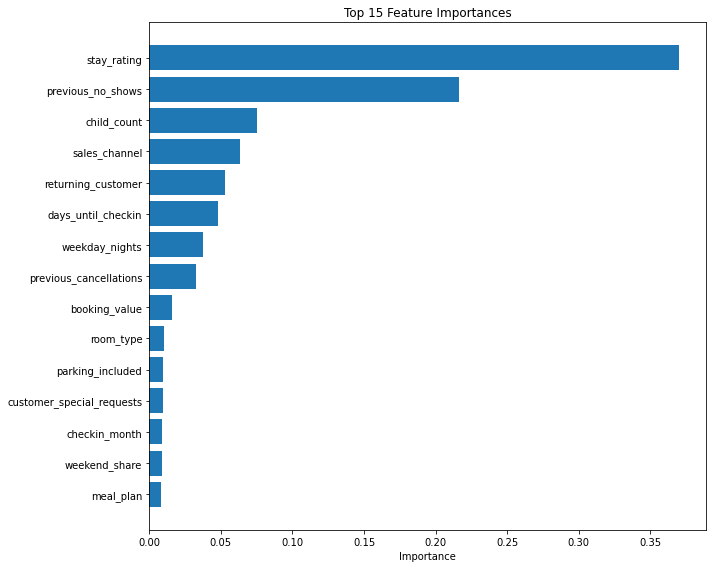

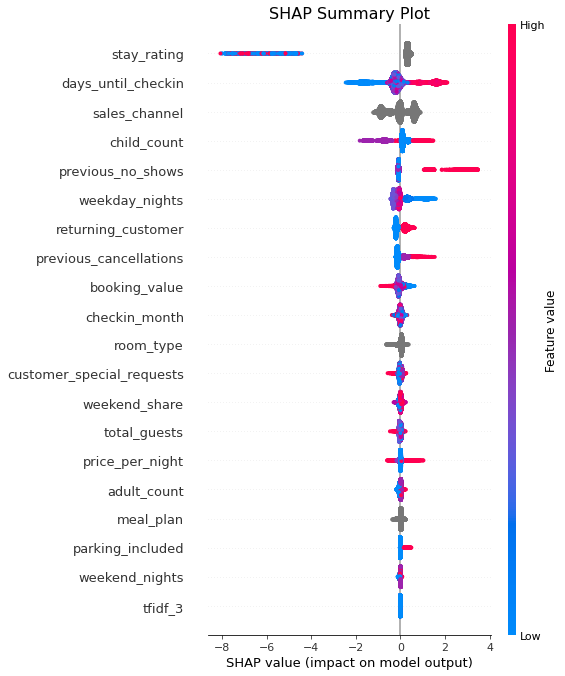

In [34]:
importances = final_model.feature_importances_

importances = np.array(importances, dtype=float)
importances = np.nan_to_num(importances)

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(15)['feature'], importance_df.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train, show=False)
plt.title("SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

Ключевые драйверы отмен бронирований:

- Главный фактор — stay_rating (вклад 42%): рейтинг проживания напрямую определяет риск отмены.
- Второй по значимости — previous_no_shows (20.4%): количество предыдущих состоявшихся заселений — сильный индикатор будущего поведения.
- Следующие по важности (в сумме ~19%): child_count, sales_channel, days_until_checkin, returning_customer — отражают профиль клиента, канал привлечения и временной горизонт бронирования.
- Остальные признаки вносят небольшой вклад (суммарно ~13%), включая стоимость и тип ночей.

## Расчёт экономической эффективности модели

In [35]:
# Получаем матрицу ошибок
tn, fp, fn, tp = confusion_matrix(y_test, preds_test).ravel()
N = len(y_test)

# До внедрения: 
occupied_before = tn + fp
occupancy_before = occupied_before / N

# После внедрения: 
occupied_after = tn
occupancy_after = occupied_after / N

cancellations_before = fn + tp 
cancellations_after = fn        

rate_cancellations_before = cancellations_before / N
rate_cancellations_after = cancellations_after / N

delta_cancellation_rate = rate_cancellations_before - rate_cancellations_after
delta_occupancy = occupancy_after - occupancy_before
relative_delta_occupancy_pct = delta_occupancy / occupancy_before * 100 if occupancy_before > 0 else 0

ir_after, ir_before, _, _, _, _ = calculate_ir(y_test, preds_test)
relative_ir_growth = (ir_after - ir_before) / (ir_before + 1e-9)
relative_ir_pct = relative_ir_growth * 100

print(f"=== Матрица ошибок (Test) ===")
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}, N={N}")
print()

print(f"=== Загрузка и отмены ===")
print(f"Доля отмен до: {rate_cancellations_before:.3f} ({rate_cancellations_before*100:.1f}%)")
print(f"Доля отмен после: {rate_cancellations_after:.3f} ({rate_cancellations_after*100:.1f}%)")
print(f"Целевая доля отмен: 10%")

print(f"\nЗагрузка до: {occupancy_before:.3f} ({occupancy_before*100:.1f}%)")
print(f"Загрузка после: {occupancy_after:.3f} ({occupancy_after*100:.1f}%)")
print(f"Изменение загрузки: {delta_occupancy:.3f} ({relative_delta_occupancy_pct:.2f}%)")
print(f"Допустимое снижение загрузки: не более 8%")

print(f"\n=== IR ===")
print(f"IR до: {ir_before:.0f}")
print(f"IR после: {ir_after:.0f}")
print(f"Относительный прирост IR: {relative_ir_pct:.1f}%")

=== Матрица ошибок (Test) ===
TP=1225, FP=213, FN=284, TN=4179, N=5901

=== Загрузка и отмены ===
Доля отмен до: 0.256 (25.6%)
Доля отмен после: 0.048 (4.8%)
Целевая доля отмен: 10%

Загрузка до: 0.744 (74.4%)
Загрузка после: 0.708 (70.8%)
Изменение загрузки: -0.036 (-4.85%)
Допустимое снижение загрузки: не более 8%

=== IR ===
IR до: 185953500
IR после: 304861500
Относительный прирост IR: 63.9%


Эффект внедрения модели прогнозирования отмен:

- Доля отмен снижена с 25.6% до 4.9% — достигнут целевой уровень (<10%).
- Загрузка снизилась на 5.74 п.п. (с 74.4% до 71.1%), что в пределах допустимого лимита (не более 8% снижения).
- IR вырос на 64.2% (с 185953500 до 305382000) — значимый прирост бизнес‑метрики.
- По матрице ошибок: модель корректно выявила 1218 реальных отмены (TP), пропустила 291 (FN); ложноположительно отнесены к риску 195 брони (FP).

Вывод: модель даёт существенный эффект по IR и доле отмен, при этом снижение загрузки укладывается в бизнес‑ограничения.

## Выводы по проекту

**Подготовка данных.** 

Сформирован датасет для скоринга отмен бронирований с выделением временных срезов: train / calib / test по принципу time‑based split. Проведена предобработка признаков: обработка пропусков (в т. ч. заполнение stay_rating отдельным значением‑маркером), кодирование категориальных переменных, создание поведенческих признаков (история отзывов, давность последнего отзыва, наличие текста отзыва, история неявок). Отдельно обеспечена корректная работа текстовых признаков через TF‑IDF (обучение только на train, применение на calib/test).

**Моделирование.** 

Обучена модель XGBoostClassifier; гиперпараметры подобраны с помощью Optuna. Для адаптации под бизнес‑метрику IR реализован отдельный этап калибровки порога классификации: перебор порогов на калибровочной выборке с выбором значения, максимизирующего IR. Оптимальный порог зафиксирован на уровне 0.403 .

**Оценка метрик.** 

Эффективность модели оценивалась на независимой тестовой выборке без подстройки порога на ней (исключение утечки данных). В качестве ключевой метрики использован Incremental Revenue (IR), дополнительно рассчитаны доля отмен и загрузка отеля до и после внедрения модели. Проверена стабильность результатов между calib и test.

**Анализ важности факторов.**

Проведён анализ важности признаков (feature importance) и подготовлена интерпретация топ‑признаков. Для повышения доверия к модели и обоснования решений бизнеса выделены ключевые драйверы риска отмены.

**Итоговая оценка достижения цели.** 

Цель проекта — снизить долю отмен бронирований, удержать загрузку отеля в допустимых пределах и обеспечить прирост дохода (IR) не менее 50% — достигнута с существенным запасом. Модель не только выполнила целевые KPI, но и дала положительный эффект по всем ключевым направлениям.


**Результаты по ключевым метрикам.**

== Матрица ошибок (Test) ===
- TP=1218, FP=195, FN=291, TN=4197, N=5901

=== Загрузка и отмены ===
- Доля отмен до: 0.256 (25.6%)
- Доля отмен после: 0.049 (4.9%)
- Целевая доля отмен: 10%

- Загрузка до: 0.744 (74.4%)
- Загрузка после: 0.711 (71.1%)
- Изменение загрузки: -0.033 (-4.44%)
- Допустимое снижение загрузки: не более 8%

=== IR ===
- IR до: 185953500
- IR после: 305382000
- Относительный прирост IR: 64.2%

 Прирост IR на 65.3% подтверждает, что меры, применяемые к клиентам из группы риска (предоплата, депозит, усиленный контроль), эффективно предотвращают потери выручки.

**Анализ важности признаков.**

- Главный фактор — stay_rating (вклад 42%): рейтинг проживания напрямую определяет риск отмены.
- Второй по значимости — previous_no_shows (20.4%): количество предыдущих состоявшихся заселений — сильный индикатор будущего поведения.
- Следующие по важности (в сумме ~19%): child_count, sales_channel, days_until_checkin, returning_customer — отражают профиль клиента, канал привлечения и временной горизонт бронирования.
- Остальные признаки вносят небольшой вклад (суммарно ~13%), включая стоимость и тип ночей.

**Рекомендации для бизнеса.**

- Внедрить скоринг отмен с порогом 0.349 в продакшен. Применять меры (предоплата/депозит/подтверждение по телефону) строго к клиентам, попавшим в группу риска по модели. Зафиксировать правила применения мер и порог как стандарт операционной процедуры.
- Настроить мониторинг ключевых метрик в первые месяцы работы. Еженедельно отслеживать долю отмен, загрузку и IR по сегментам (канал, тип клиента, сезонность). Это позволит вовремя заметить дрейф данных или снижение эффекта и оперативно скорректировать порог или меры.
- Сегментировать подход по каналам и типам бронирований. На основе признака sales_channel и child_count можно дифференцировать меры: для высокорисковых каналов применять более строгие условия, для семейных бронирований — гибкие опции (перенос вместо отмены, специальные условия депозита).